## 0. Libraries

In [2]:
# Import LoopDetect core and numpy
import numpy as np
import loopdetect.core as ld
import loopdetect.examples as lde
import numdifftools
import pandas as pd

from scipy.integrate import odeint
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

d:\Work\StudentJob\Jana Wolf\LoopDetect_2025\env\lib\loopdetect_python_3.12\Lib\site-packages\loopdetect\examples.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. Configuration

In [3]:
from matplotlib import rcParams

rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "text.usetex": True,  # requires LaTeX installation
    "axes.linewidth": 1.2,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 14,
    "figure.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.major.size": 6,
    "ytick.minor.size": 3,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
})

colors = ['#EE7733', '#0077BB', '#33BBEE', '#EE3377', '#CC3311', '#009988', '#BBBBBB']

## 2. Main reproduction

#### **Example 2: Model of complex formation**

The model of complex formation has also been investigated in [4]. It is a basic
model of a bilinear reaction in that two species, A, B, reversibly form a complex AB
together. Only the two reactions of complex formation and complex decomposition
are modelled. The model contains three species, two rate coefficients and no other
parameters.

$$\frac{dA}{dt} = -k_1\,A\,B + k_2\,AB$$

$$\frac{dB}{dt} = -k_1\,A\,B + k_2\,AB$$

$$\frac{d(AB)}{dt} = k_1\,A\,B - k_2\,AB$$

We employed the following parameter set: $k_1 = 1$, $k_2 = 2$, with initial conditions
$A = 10, B = 5, C = 2$ (C should change to AB).

In [4]:
def model_complex_formation(y, params):
    A, B, AB = y
    k1, k2 = params
    dAdt = -k1 * A * B + k2 * AB
    dBdt = -k1 * A * B + k2 * AB
    dABdt = k1 * A * B - k2 * AB
    
    return np.array([dAdt, dBdt, dABdt], dtype=float)

def solve_complex_formation(initial_conditions, time_points, k1, k2):
    def model(t, x):
        return model_complex_formation(x, (k1, k2))
    sol = solve_ivp(model, [time_points[0], time_points[-1]], initial_conditions,
                    t_eval=time_points, method='RK45', rtol=1e-6)
    return sol

In [5]:
# Parameters from supplementary material
params=[1.0, 2.0]
s_star = [1.0, 1.0, 1.0]

# Parameters not yet in supplement data
perturbation_point = 0.2

In [6]:
# Jacocbian calculation
j_matrix = numdifftools.Jacobian(lambda x: model_complex_formation(x, params),method="central")(s_star)
signed_jacobian = np.sign(j_matrix)

In [7]:
print("Jacobian matrix:")
print(j_matrix)
print("Signed Jacobian matrix:")
print(signed_jacobian)

Jacobian matrix:
[[-1. -1.  2.]
 [-1. -1.  2.]
 [ 1.  1. -2.]]
Signed Jacobian matrix:
[[-1. -1.  1.]
 [-1. -1.  1.]
 [ 1.  1. -1.]]


In [8]:
# Find loops
res_tab_complex = ld.find_loops_vset(model_complex_formation,
                                     vset=[s_star],
                                     params=params,
                                     max_num_loops=10)
print(res_tab_complex['loop_rep'][0])

           loop  length  sign
0     (0, 1, 0)       2     1
1  (0, 1, 2, 0)       3    -1
2     (0, 2, 0)       2     1
3  (0, 2, 1, 0)       3    -1
4     (1, 2, 1)       2     1
5        (0, 0)       1    -1
6        (1, 1)       1    -1
7        (2, 2)       1    -1


In [9]:
loop_list = ld.find_loops(j_matrix)
ld.loop_summary(loop_list)

length,1,2,3
total,3,3,2
neg,3,0,2
pos,0,3,0


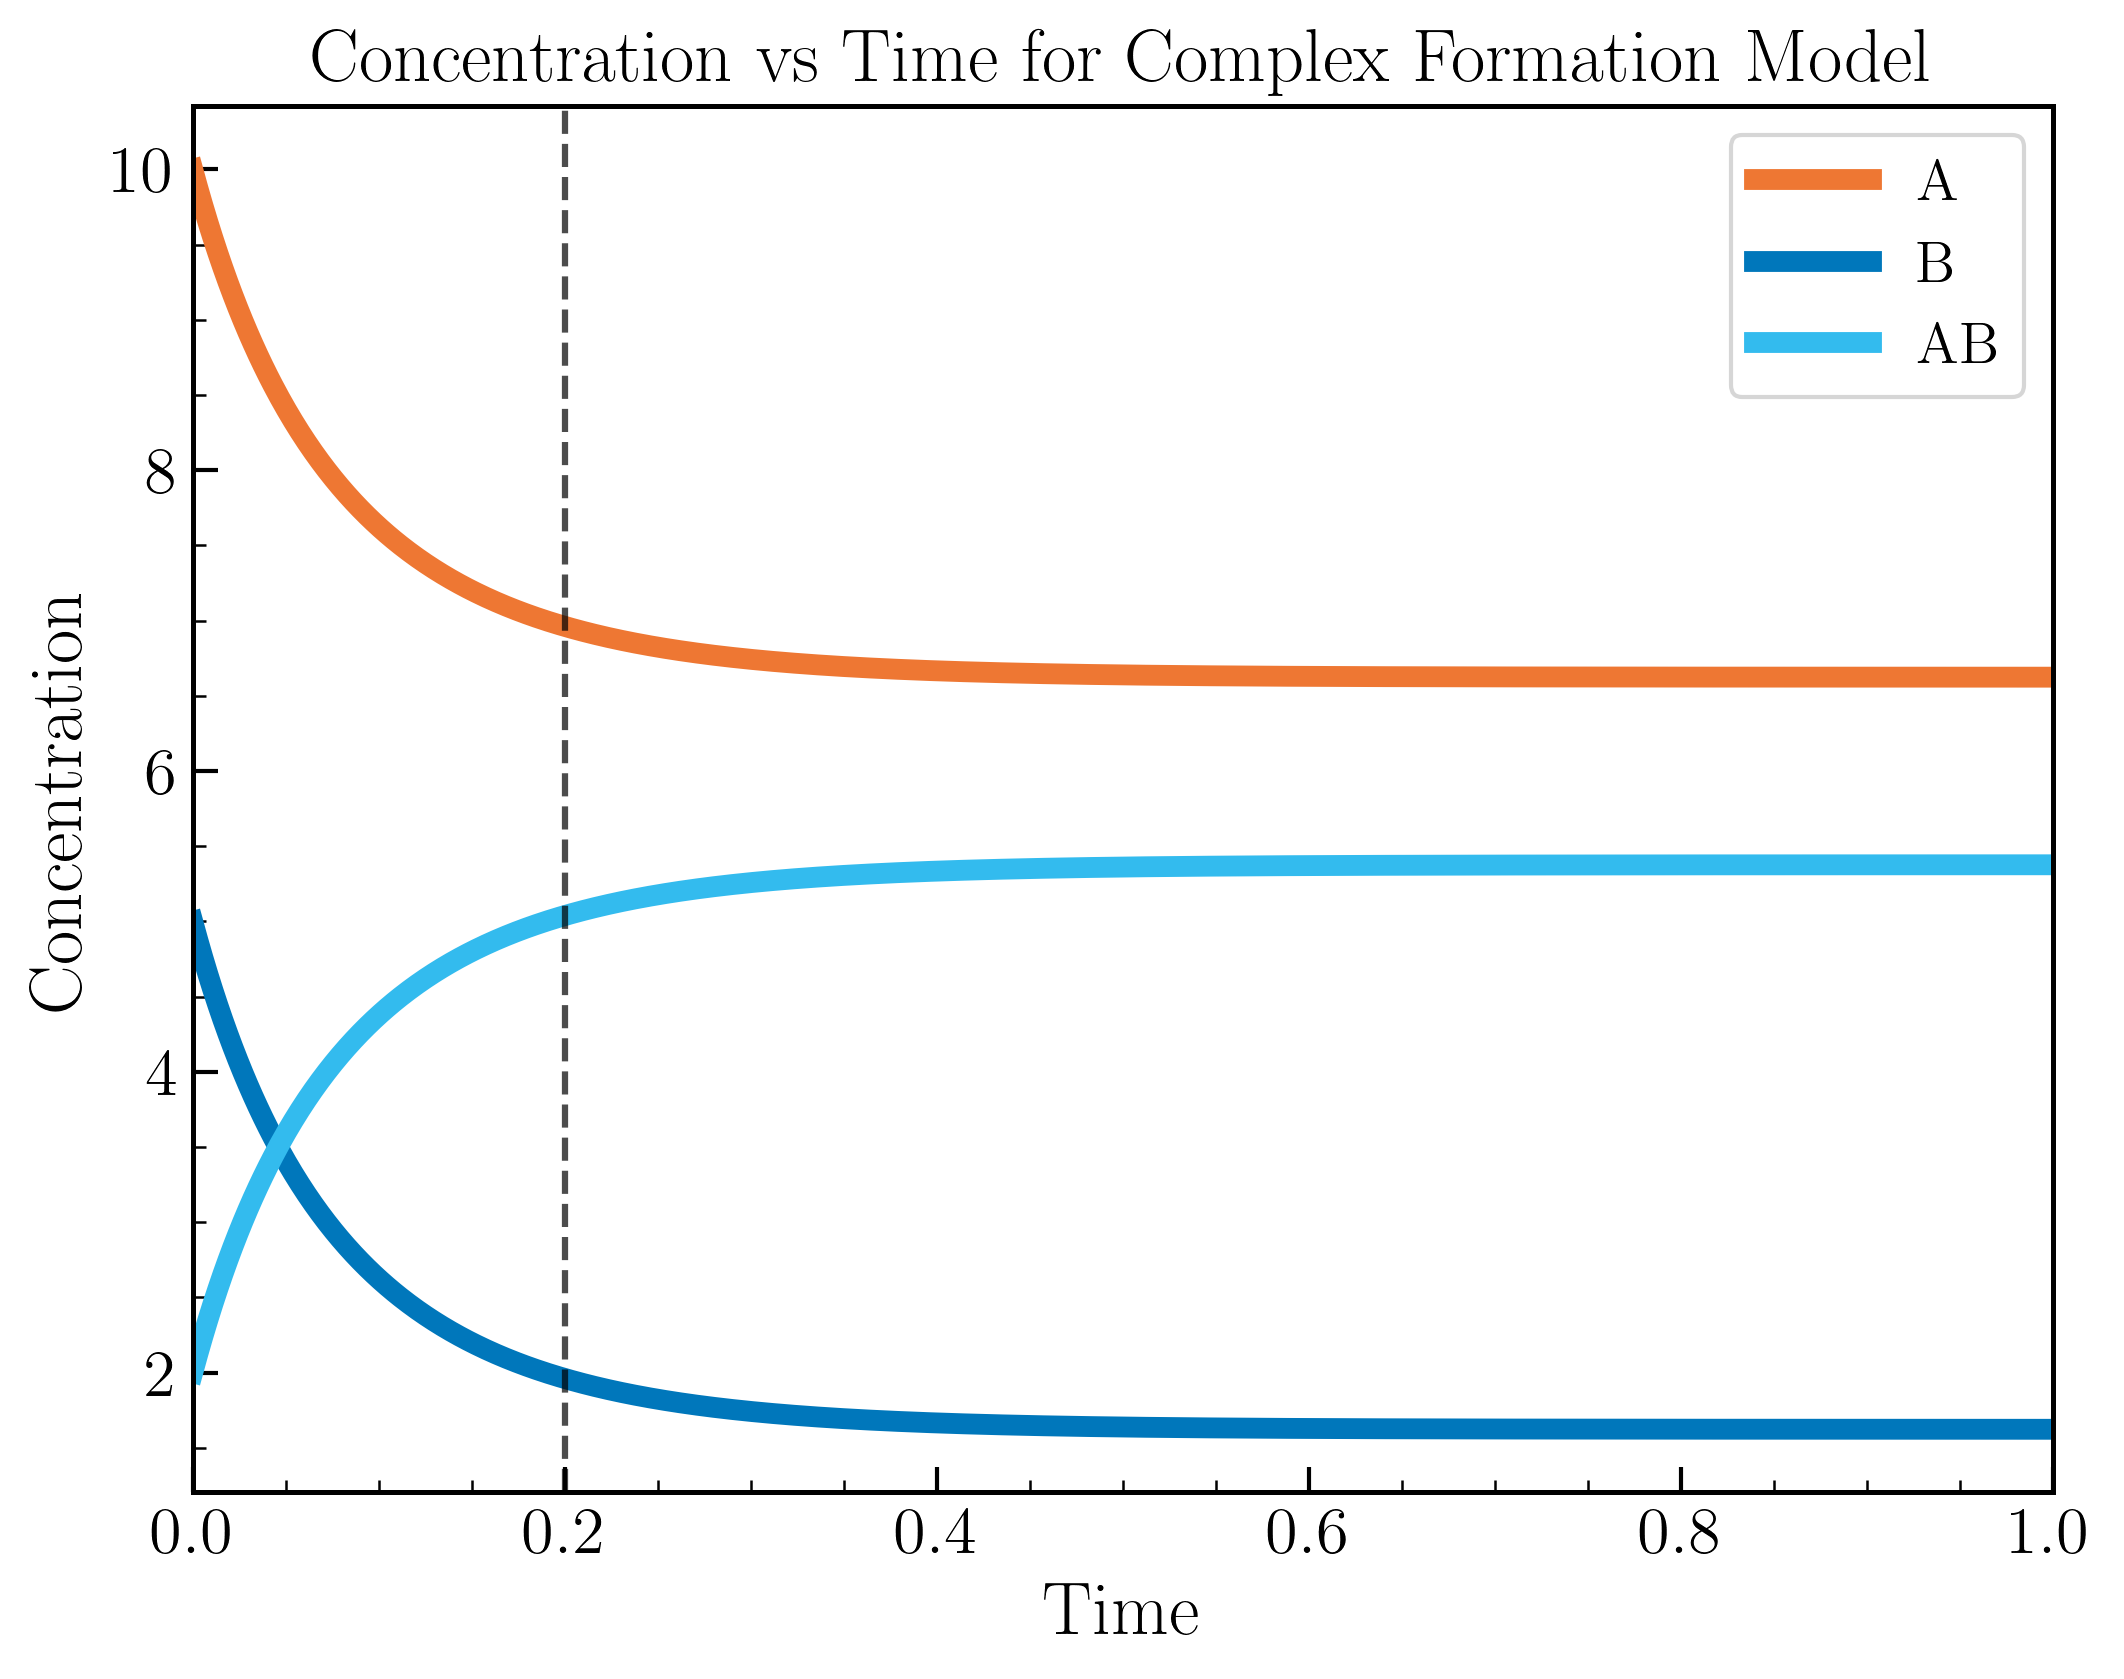

In [10]:
time_points = np.linspace(0, 1, 1111) # delta t = 0.01
initial_conditions = [10.0, 5.0, 2.0]  # Initial concentrations of A, B, and AB
k1 = 1.0  # Rate constant for complex formation
k2 = 2.0  # Rate constant for complex dissociation

sol = solve_complex_formation(initial_conditions, time_points, k1, k2)

plt.figure(figsize=(8, 6))
for i, c in enumerate(colors[:3]):
    plt.plot(time_points, sol.y[i], lw=5, color=c, label=f"S{i+1}")
# plt.plot(sol.t, sol.y.T)
plt.axvline(x=0.2, color='black', linestyle='--', lw=1.5, alpha=0.7)
plt.xlim(0, 1)
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.title('Concentration vs Time for Complex Formation Model')
plt.legend(['A', 'B', 'AB'])
plt.show()

In [11]:
# Take initial conditions 1 at t = 0.2 of the the above simulation
initial_conditions_1 = sol.y[:, 20]  # Corresponds to t = 0.2

# Pertubation analysis for complex formation model (Perturb A - fixed)
delta_t = 0.001
perturbation_point = 0.2 # start perturbation at t=0.2
time_index = int(perturbation_point/delta_t)
cap_range = 0.05  # time range to capture before and after perturbation
time_points_1 = np.linspace(-cap_range, 0, int(cap_range/delta_t) + 1) # delta 1= 0.001
initial_conditions_1 = sol.y[:, time_index]  # Initial concentrations of A, B, and AB
# Take partial values for sol_1 at the previous simulation
sol_1_005 = sol.y[:, time_index - int(cap_range/delta_t):time_index + 1]  # Corresponds to t = -0.05 to t = 0.0

time_points_2 = np.linspace(0, cap_range, int(cap_range/delta_t) + 1) # delta 2= 0.001
initial_conditions_2 = [40.0, sol.y[1, time_index], sol.y[2, time_index]]  # Initial concentrations of A, B, and AB
sol_2 = solve_complex_formation(initial_conditions_2, time_points_2, k1, k2)

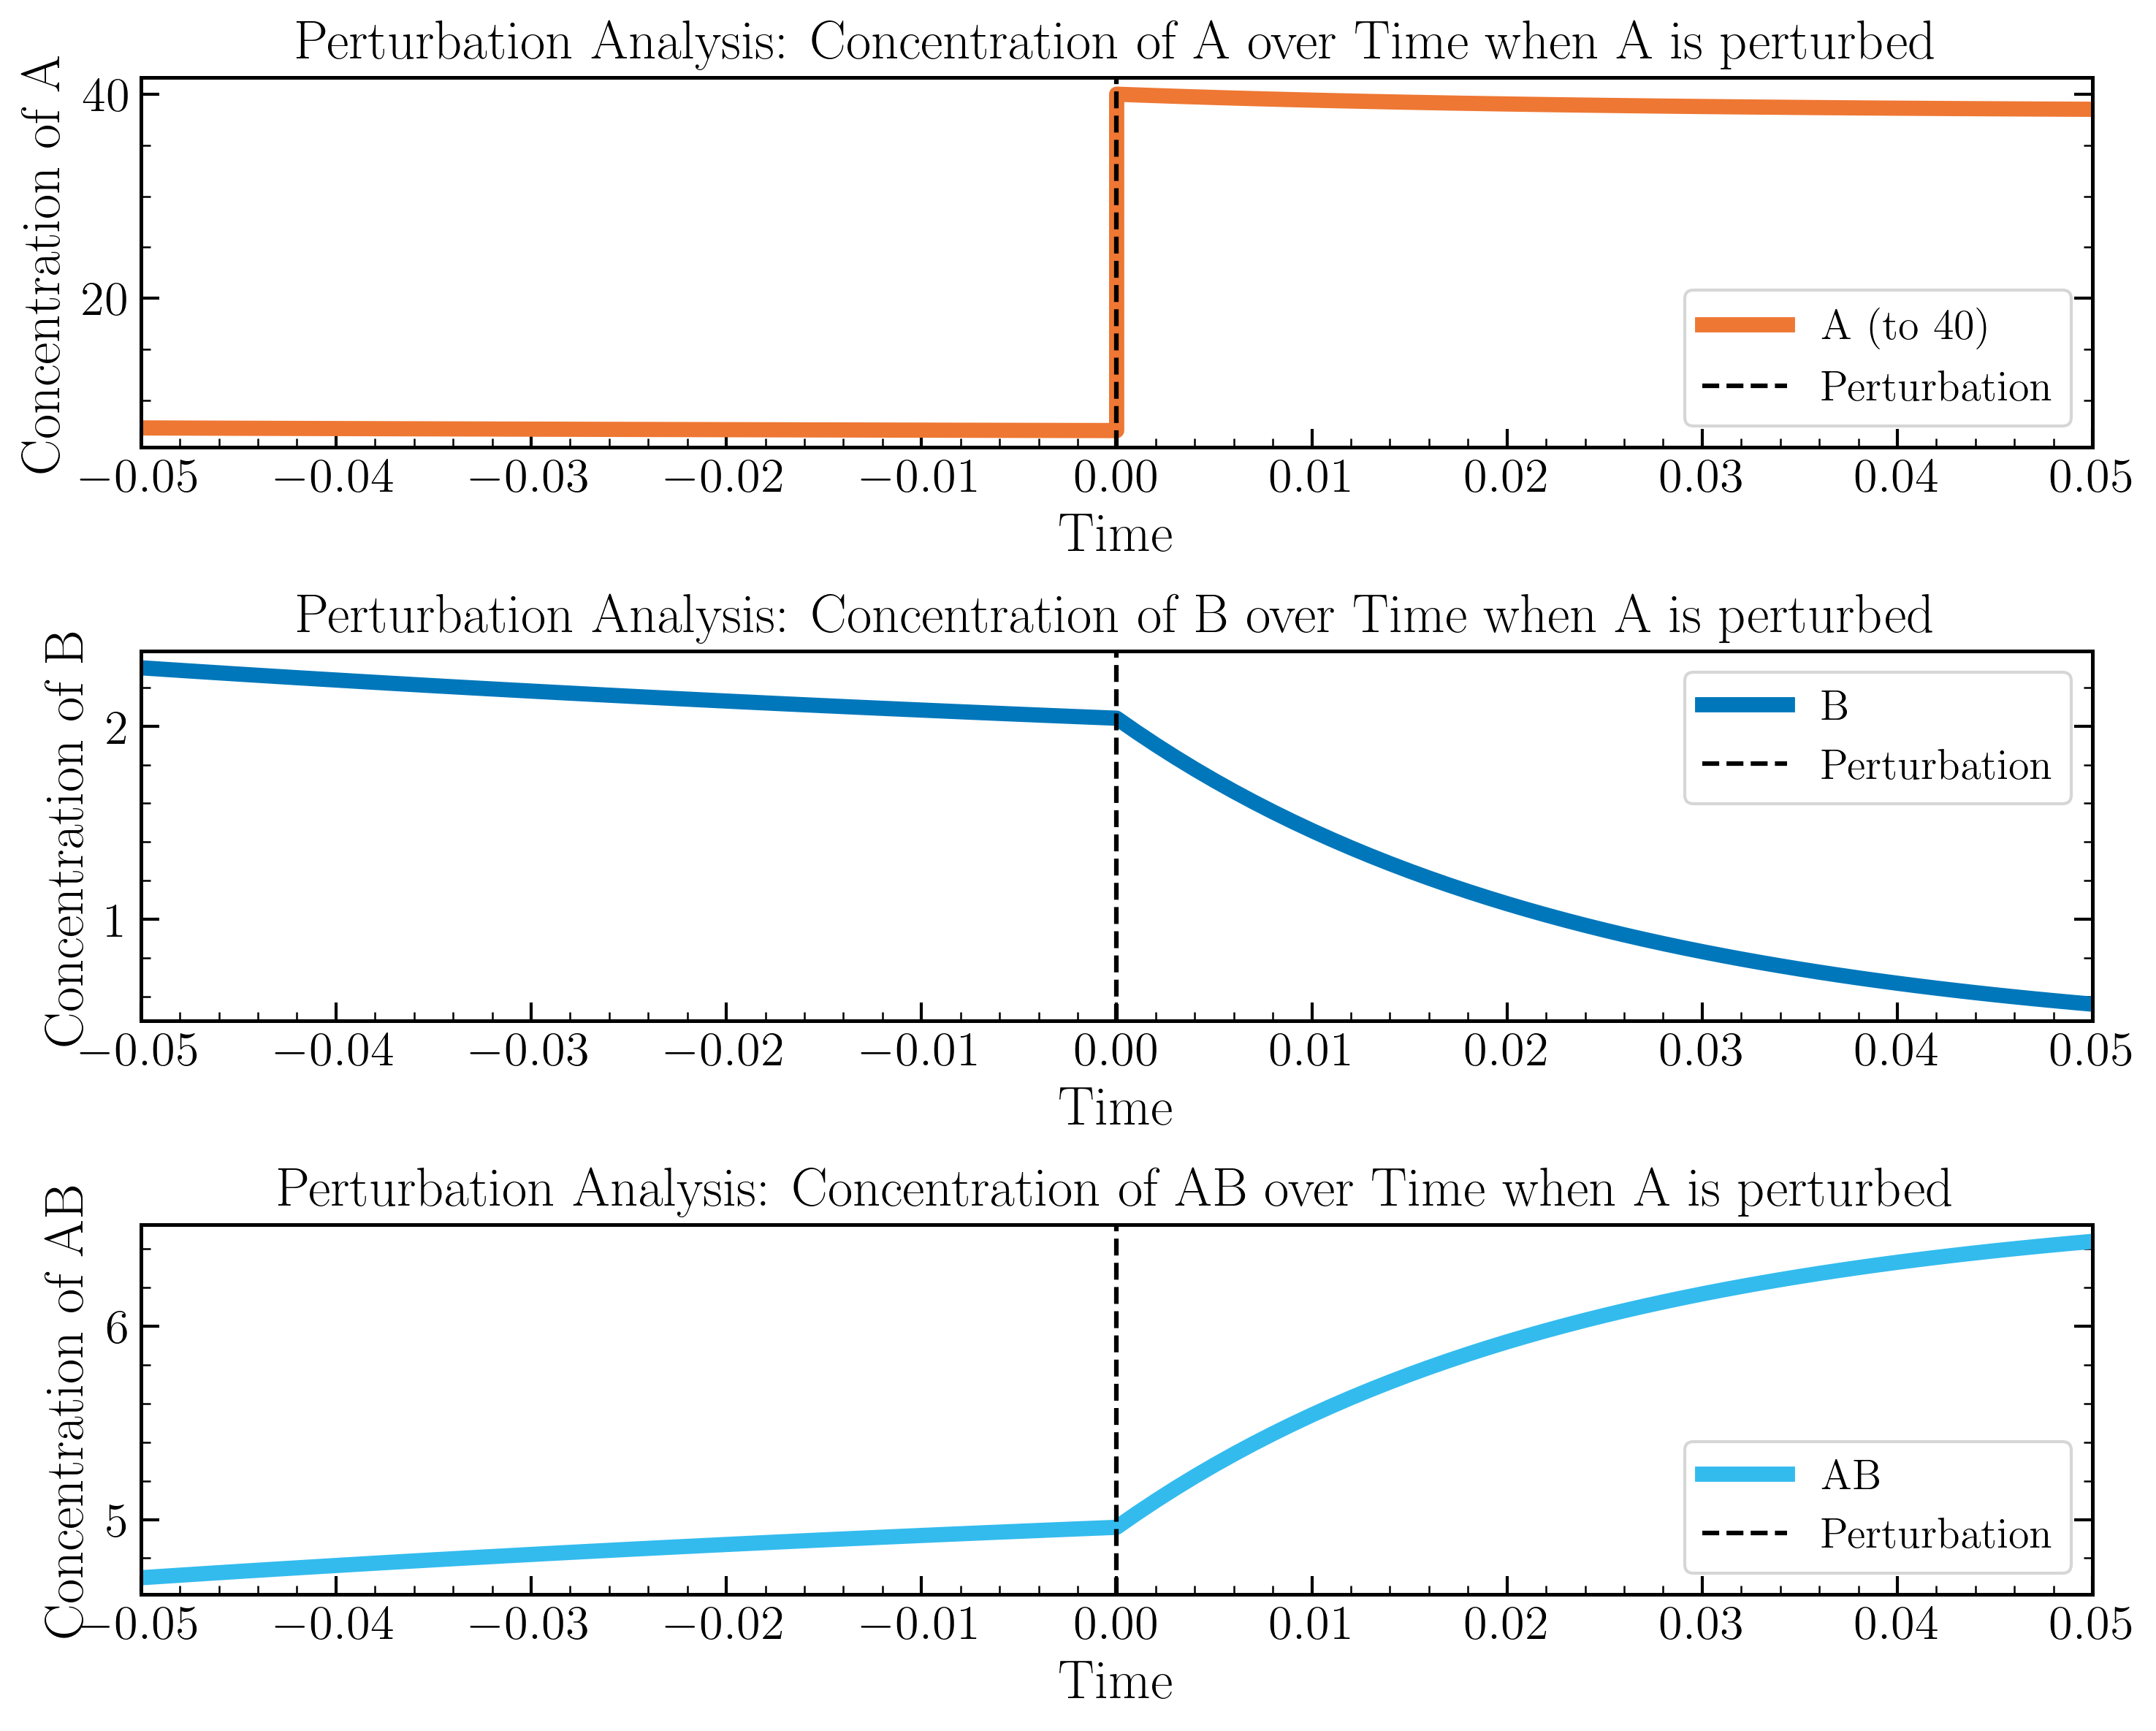

In [12]:
# Plot pertubation results (3 plots for A, B, and C in one figure)
fig, axs = plt.subplots(3, 1, figsize=(10, 8))
# Plot for A
time_A = np.concatenate((time_points_1, time_points_2))
value_A = np.concatenate((sol_1_005[0], sol_2.y[0]))
axs[0].plot(time_A, value_A, lw=5, color=colors[0], label='A (to 40)')
# Black dashed line at t=0.0
axs[0].axvline(x=0.0, color='black', linestyle='--', lw=1.5, label='Perturbation')
axs[0].set_xlabel('Time')
axs[0].set_ylabel('Concentration of A')
axs[0].set_title('Perturbation Analysis: Concentration of A over Time when A is perturbed')
axs[0].set_xlim(-cap_range, cap_range)
axs[0].yaxis.set_ticks_position('both')
axs[0].set_xticks(np.arange(-cap_range, cap_range+0.005, 0.01))
axs[0].legend(loc='lower right')
# Plot for B
time_B = np.concatenate((time_points_1, time_points_2))
value_B = np.concatenate((sol_1_005[1], sol_2.y[1]))
axs[1].plot(time_B, value_B, lw=5, color=colors[1], label='B') # (from 5.0 to 5.0)
# Black dashed line at t=0.0
axs[1].axvline(x=0.0, color='black', linestyle='--', lw=1.5, label='Perturbation')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('Concentration of B')
axs[1].set_title('Perturbation Analysis: Concentration of B over Time when A is perturbed')
axs[1].set_xlim(-cap_range, cap_range)
axs[1].yaxis.set_ticks_position('both')
axs[1].set_xticks(np.arange(-cap_range, cap_range+0.005, 0.01))
axs[1].legend(loc='upper right')
# Plot for AB
time_AB = np.concatenate((time_points_1, time_points_2))
value_AB = np.concatenate((sol_1_005[2], sol_2.y[2]))
axs[2].plot(time_AB, value_AB, lw=5, color=colors[2], label='AB') # (from 2.0 to 2.0)
# Black dashed line at t=0.0
axs[2].axvline(x=0.0, color='black', linestyle='--', lw=1.5, label='Perturbation')
axs[2].set_xlabel('Time')
axs[2].set_ylabel('Concentration of AB')
axs[2].set_title('Perturbation Analysis: Concentration of AB over Time when A is perturbed')
axs[2].set_xlim(-cap_range, cap_range)
axs[2].yaxis.set_ticks_position('both')
axs[2].set_xticks(np.arange(-cap_range, cap_range+0.005, 0.01))
axs[2].legend(loc='lower right')
plt.tight_layout()
plt.show()

In [13]:
# Pertubation analysis for complex formation model (Perturb B)
time_points_1 = np.linspace(-0.05, 0, 51) # delta 1= 0.001
initial_conditions_1 = sol.y[:, 200]  # Initial concentrations of A, B, and AB
# Take partial values for sol_1 at the previous simulation
sol_1_005 = sol.y[:, 150:201]  # Corresponds to t = -0.05 to t = 0.0

time_points_2 = np.linspace(0, 0.05, 51) # delta 2= 0.001
initial_conditions_2 = [sol.y[0, 200], 10.0, sol.y[2, 200]]  # Initial concentrations of A, B, and AB
sol_2 = solve_complex_formation(initial_conditions_2, time_points_2, k1, k2)

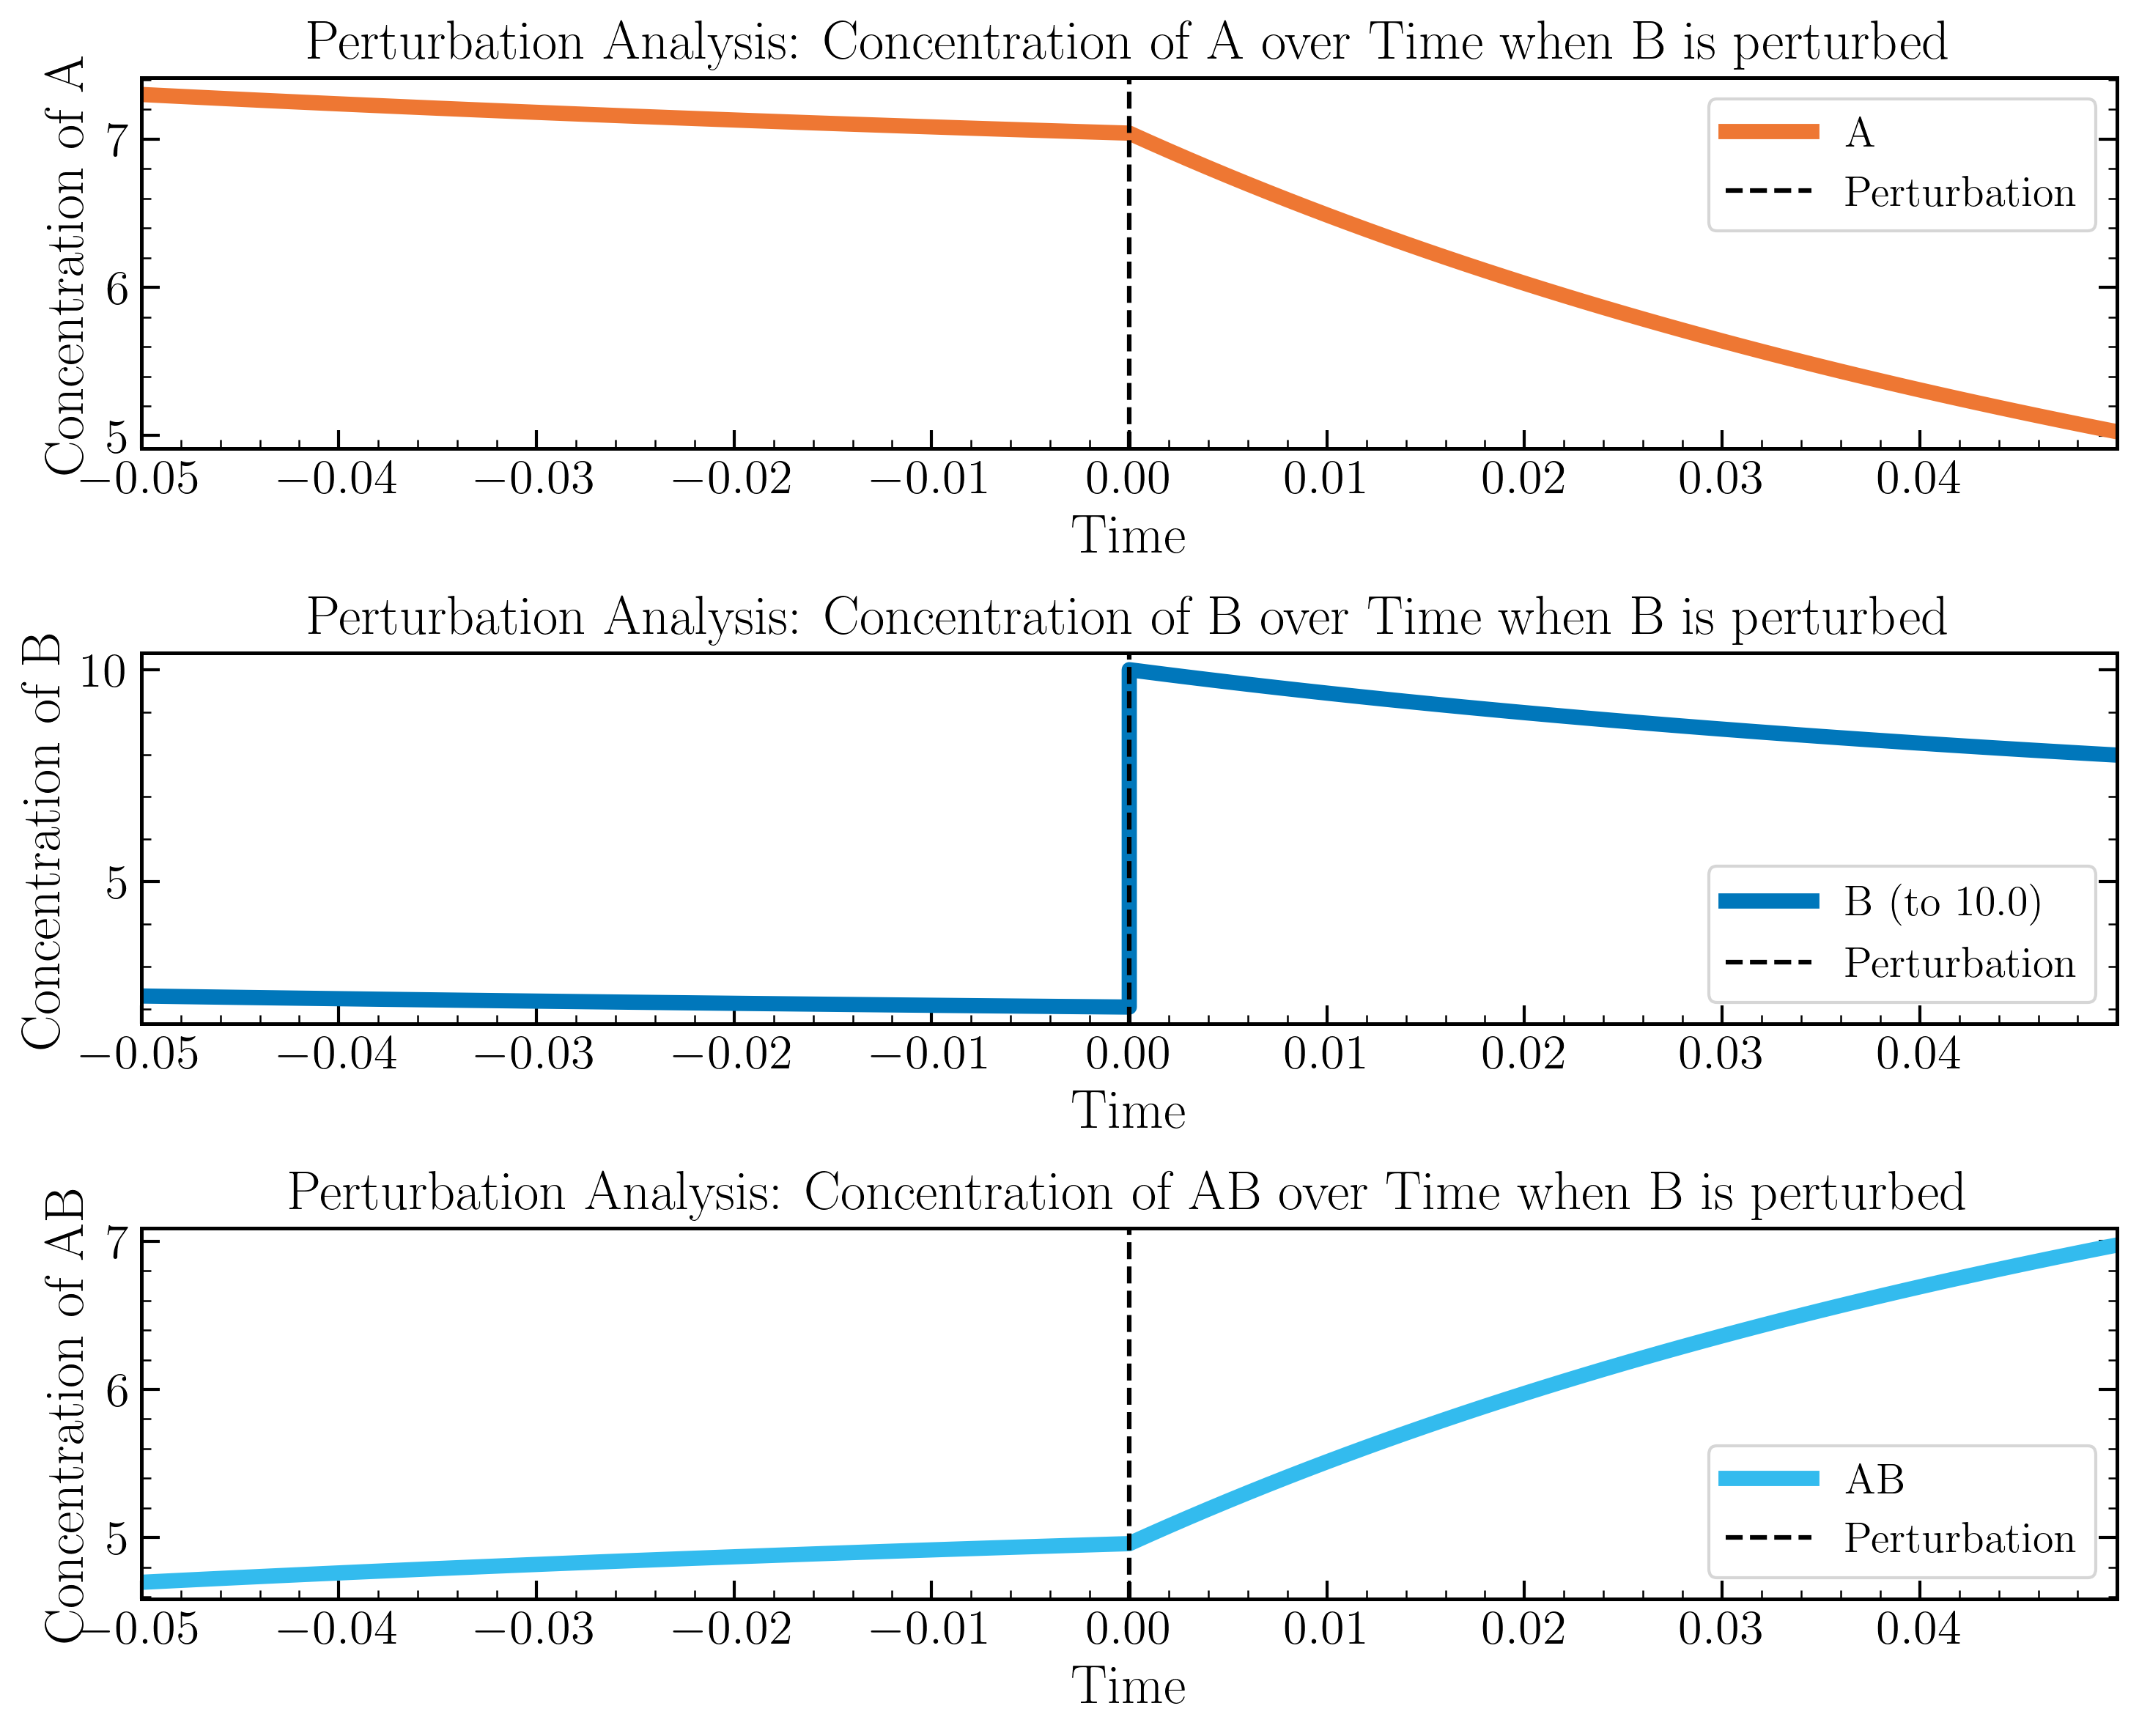

In [14]:
# Plot pertubation results (3 plots for A, B, and C in one figure)
fig, axs = plt.subplots(3, 1, figsize=(10, 8))
# Plot for A
time_A = np.concatenate((time_points_1, time_points_2))
value_A = np.concatenate((sol_1_005[0], sol_2.y[0]))
axs[0].plot(time_A, value_A, lw=5, color=colors[0], label='A')
# Black dashed line at t=0.0
axs[0].axvline(x=0.0, color='black', linestyle='--', lw=1.5, label='Perturbation')
axs[0].set_xlabel('Time')
axs[0].set_ylabel('Concentration of A')
axs[0].set_title('Perturbation Analysis: Concentration of A over Time when B is perturbed')
axs[0].set_xlim(-0.05, 0.05)
axs[0].yaxis.set_ticks_position('both')
axs[0].set_xticks(np.arange(-0.05, 0.05, 0.01))
axs[0].legend(loc='upper right')
# Plot for B
time_B = np.concatenate((time_points_1, time_points_2))
value_B = np.concatenate((sol_1_005[1], sol_2.y[1]))
axs[1].plot(time_B, value_B, lw=5, color=colors[1], label='B (to 10.0)') # (from 5.0 to 5.0)
# Black dashed line at t=0.0
axs[1].axvline(x=0.0, color='black', linestyle='--', lw=1.5, label='Perturbation')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('Concentration of B')
axs[1].set_title('Perturbation Analysis: Concentration of B over Time when B is perturbed')
axs[1].set_xlim(-0.05, 0.05)
axs[1].yaxis.set_ticks_position('both')
axs[1].set_xticks(np.arange(-0.05, 0.05, 0.01))
axs[1].legend(loc='lower right')
# Plot for AB
time_AB = np.concatenate((time_points_1, time_points_2))
value_AB = np.concatenate((sol_1_005[2], sol_2.y[2]))
axs[2].plot(time_AB, value_AB, lw=5, color=colors[2], label='AB') # (from 2.0 to 2.0)
# Black dashed line at t=0.0
axs[2].axvline(x=0.0, color='black', linestyle='--', lw=1.5, label='Perturbation')
axs[2].set_xlabel('Time')
axs[2].set_ylabel('Concentration of AB')
axs[2].set_title('Perturbation Analysis: Concentration of AB over Time when B is perturbed')
axs[2].set_xlim(-0.05, 0.05)
axs[2].yaxis.set_ticks_position('both')
axs[2].set_xticks(np.arange(-0.05, 0.05, 0.01))
axs[2].legend(loc='lower right')
plt.tight_layout()
plt.show()

In [16]:
pd.DataFrame(sol_1_005)

,0,1,2,3,4,5,6,7,8,9,...,41,42,43,44,45,46,47,48,49,50
0,7.301467,7.294829,7.288259,7.281758,7.275324,7.268957,7.262655,7.256419,7.250247,7.244139,...,7.078344,7.07398,7.06966,7.065383,7.061149,7.056957,7.052807,7.048698,7.04463,7.040603
1,2.301467,2.294829,2.288259,2.281758,2.275324,2.268957,2.262655,2.256419,2.250247,2.244139,...,2.078344,2.07398,2.06966,2.065383,2.061149,2.056957,2.052807,2.048698,2.04463,2.040603
2,4.698533,4.705171,4.711741,4.718242,4.724676,4.731043,4.737345,4.743581,4.749753,4.755861,...,4.921656,4.92602,4.93034,4.934617,4.938851,4.943043,4.947193,4.951302,4.95537,4.959397


## 3. Additional features

### 3.1. Add subject ID to make the loop result more comprehensible

In [18]:
id_to_subject = {
    0: "A",
    1: "B",
    2: "AB"
}

df = pd.DataFrame(res_tab_complex['loop_rep'][0]).sort_values(by=['length','loop'])

df["loop_subject"] = df["loop"].apply(
    lambda t: tuple(id_to_subject[i] for i in t)
)

df

,loop,length,sign,loop_subject
5,"(0, 0)",1,-1,"(A, A)"
6,"(1, 1)",1,-1,"(B, B)"
7,"(2, 2)",1,-1,"(AB, AB)"
0,"(0, 1, 0)",2,1,"(A, B, A)"
2,"(0, 2, 0)",2,1,"(A, AB, A)"
4,"(1, 2, 1)",2,1,"(B, AB, B)"
1,"(0, 1, 2, 0)",3,-1,"(A, B, AB, A)"
3,"(0, 2, 1, 0)",3,-1,"(A, AB, B, A)"


### 3.2. Represent regulation relationship from Jacobian matrix

In [19]:
# Dataframe with columns: 'from', 'to', 'regulation'
# Apply id to subject mapping

regulation_info = pd.DataFrame(signed_jacobian, columns=[id_to_subject[i] for i in range(signed_jacobian.shape[1])], index=[id_to_subject[i] for i in range(signed_jacobian.shape[0])])
regulation_info = regulation_info.stack().reset_index()
regulation_info.columns = ['from', 'to', 'regulation']

# Add regulation information for each variable (-1: inhibition (negative), 1:activation (posotive)). 0 means no regulation and will not be shown in the graph.
regulation_info['regulation_words'] = regulation_info['regulation'].map({-1: 'inhibition (negative)', 1: 'activation (positive)', 0: 'no regulation'})
regulation_info

,from,to,regulation,regulation_words
0,A,A,-1.0,inhibition (negative)
1,A,B,-1.0,inhibition (negative)
2,A,AB,1.0,activation (positive)
3,B,A,-1.0,inhibition (negative)
4,B,B,-1.0,inhibition (negative)
5,B,AB,1.0,activation (positive)
6,AB,A,1.0,activation (positive)
7,AB,B,1.0,activation (positive)
8,AB,AB,-1.0,inhibition (negative)


### 3.3. Loop Summary in more detail

In [20]:
# Given dataframe from 3.1 named `df`
df

,loop,length,sign,loop_subject
5,"(0, 0)",1,-1,"(A, A)"
6,"(1, 1)",1,-1,"(B, B)"
7,"(2, 2)",1,-1,"(AB, AB)"
0,"(0, 1, 0)",2,1,"(A, B, A)"
2,"(0, 2, 0)",2,1,"(A, AB, A)"
4,"(1, 2, 1)",2,1,"(B, AB, B)"
1,"(0, 1, 2, 0)",3,-1,"(A, B, AB, A)"
3,"(0, 2, 1, 0)",3,-1,"(A, AB, B, A)"


In [21]:
# Loop summary (A different way)
loop_summary = df.groupby('length').agg(
    num_loops=('loop', 'count'),
    loops=('loop_subject', lambda x: list(x))
).reset_index()
loop_summary

,length,num_loops,loops
0,1,3,"[(A, A), (B, B), (AB, AB)]"
1,2,3,"[(A, B, A), (A, AB, A), (B, AB, B)]"
2,3,2,"[(A, B, AB, A), (A, AB, B, A)]"


In [22]:
# make an extended loop summary with added information: 'num_loops_positive', 'num_loops_negative', 'loops_positive', 'loops_negative'
# Loop positive if sign is positive, negative if sign is negative
def count_loop_types(loop_subjects, regulation_info):
    num_positive = 0
    num_negative = 0
    loops_positive = []
    loops_negative = []
    
    for loop in loop_subjects:
        sign = 1
        for i in range(len(loop)):
            from_node = loop[i]
            to_node = loop[(i + 1) % len(loop)]
            regulation = regulation_info[
                (regulation_info['from'] == from_node) & 
                (regulation_info['to'] == to_node)
            ]['regulation'].values[0]
            sign *= regulation
        if sign > 0:
            num_positive += 1
            loops_positive.append(loop)
        else:
            num_negative += 1
            loops_negative.append(loop)
    return num_positive, num_negative, loops_positive, loops_negative
loop_summary_extended = loop_summary.copy()
loop_summary_extended[['num_loops_positive', 'num_loops_negative', 'loops_positive', 'loops_negative']] = loop_summary_extended['loops'].apply(
    lambda x: pd.Series(count_loop_types(x, regulation_info))
)
loop_summary_extended

,length,num_loops,loops,num_loops_positive,num_loops_negative,loops_positive,loops_negative
0,1,3,"[(A, A), (B, B), (AB, AB)]",3,0,"[(A, A), (B, B), (AB, AB)]",[]
1,2,3,"[(A, B, A), (A, AB, A), (B, AB, B)]",0,3,[],"[(A, B, A), (A, AB, A), (B, AB, B)]"
2,3,2,"[(A, B, AB, A), (A, AB, B, A)]",2,0,"[(A, B, AB, A), (A, AB, B, A)]",[]


In [23]:
# Columns can be rearranged based on preference
cols = ['length', 'num_loops', 'num_loops_positive', 'num_loops_negative', 'loops', 'loops_positive', 'loops_negative']
loop_summary_extended = loop_summary_extended[cols]
loop_summary_extended

,length,num_loops,num_loops_positive,num_loops_negative,loops,loops_positive,loops_negative
0,1,3,3,0,"[(A, A), (B, B), (AB, AB)]","[(A, A), (B, B), (AB, AB)]",[]
1,2,3,0,3,"[(A, B, A), (A, AB, A), (B, AB, B)]",[],"[(A, B, A), (A, AB, A), (B, AB, B)]"
2,3,2,2,0,"[(A, B, AB, A), (A, AB, B, A)]","[(A, B, AB, A), (A, AB, B, A)]",[]
